# ShallowLandslider: Quick‑start Notebook

This notebook can be used to run the `ShallowLandslider` modelling component on a Landlab grid.
- ⚠️ Check placeholder paths and parameters before running end‑to‑end."
- Running the following should create a fully compatible python environment for ShallowLandslider to run:
    ```
    conda env create -f environment.yml
    conda activate shallow_landslider
    ```

## Prerequisites

- Python 3.9+ recommended
- Packages: `numpy`$\geq$ 2.0, `matplotlib`, `pandas`, `landlab`, `scipy`, `scikit-image`, `richdem`, `seaborn`, 
- Local modules available on your path: `shallow_landslide_component.py`, and `helper_functions.py` providing:
  - `get_topo`, `apply_soil_depth`, `calculate_terrain_attribute`, `generate_acceleration_grid`,
  - `pickle_or_not_to_pickle` (if using measured data)

> If running in a clean environment, install deps, e.g.:
```bash
pip install landlab numpy pandas matplotlib scipy scikit-image seaborn richdem
```

> Ensure the working directory contains your component and helper modules, or update `sys.path` accordingly.
> The component has been tested on RasterModelGrid **only**; it might not work with other types of grids

## Imports & Settings

In [1]:
# Standard imports
import os
import numpy as np
import matplotlib.pyplot as plt

# Landlab
from landlab.components import PriorityFloodFlowRouter
from landlab import imshowhs_grid

# Project modules (ensure these files are in the working directory or in PYTHONPATH)
from shallow_landslide_component import ShallowLandslider

# Utilities to help quick-start
from utils import (
    get_topo,
    apply_soil_depth,
    calculate_terrain_attribute,
    generate_acceleration_grid,
    pickle_or_not_to_pickle,
    plot_comparison_panels_with_ecdf,
    save_model_run,
    load_all_runs,
    setup_logger
)
from data_analysis import (
    extract_selected_group_props,
    plot_histograms_ecdfs_combined,
    create_performance_summary
)

# Plotting aesthetics
plt.style.use('seaborn-v0_8')

## Configuration 1 (edit these for your study area)

In [2]:
# DEM & flow settings
config = {
    'dem_info': {
        'dem_type': 'SRTMGL1',
        'buffer': 0.01,
        'smooth_num': 4,
        'plot_dem': True,
        'api_key': 'f08b2664772eb044626d5cb114924de1' # required to download DEMs from OpenTopography
    },
    'flow_params': {
        'flow_metric': 'D8',
        'separate_hill_flow': True,
        'depression_handling': 'fill',
        'update_hill_depressions': True,
        'accumulate_flow': True,
    },
    'soil_params': { # Edit these soil properties
        'angle_int_frict': 30,      # degrees
        'cohesion_eff': 15e3,       # Pa
        'submerged_soil_proportion': 0.5, # Proportion of soil layer under water (default: 0.5)
        'max_soil_depth': 1.5,      # m
        'plot_soil': True, # Plot soil-depth distribution
        
        # Soil thickness distribution
        'distribution': 'curvature', # 'uniform'|'elevation'|'drainage_area'|'curvature'|'mean_elev_curv'
        'relationship': 'linear_std_local', # for "distribution" == "elevation", "relationship" == "linear", "exponential", "power", "sigmoid"
        # for "distribution" == "curvature", "relationship" == "linear", "linear_std_local", "linear_std_global", "piecewise"
        
        # Elevation-based params
        'decay_rate': 1.0, # for relationship == "exponential"
        'exponent': 2.0, # for relationship == "power"
        
        # Drainage-area based params
        'drainage_transform': 'threshold',
        'drainage_threshold': 1e6,
        'drainage_power': 0.3,
        
        # Curvature-based params
        'P0': 0.05, 'h_star': 1.0, 'D': 0.01, 'h_min': 0.1, 'h_no_ss': 0.0,
    },
    'pga': {
        'horizontal_max': 0.6,
        'vertical_max': 0.2,
        'distribution': 'uniform', # Distribution shape: "uniform" (default), "circular", "square", "diamond", or "exponential"
        'plot_grids': False, # True will plot the PGA grids
    },
    'simulation': {
        'time_shaking': 10, # seconds (used for Newmark displacement if enabled)
        'displacement_threshold': 0.0,
        'aspect_interval': 20, # interval for topographic aspect zones
        'random_seed': 5000,
        'handle_small_regions': 'merge',
        'selection_method': 'probabilistic', # or 'pga_weighted'
        'proportion_method': 'conservative', # 'empirical'|'statistical'|'risk_profile'|'adaptive'|'conservative'
        'custom_proportion': 0.25, # Used to select specific number of landslides. Use if selected landslides >> modelled
        'compute_displacement': True, # Used to calculate Newmark displacement and sediment paths
        'enable_runout': False,
        'update_soil': False
    },
    'output': {
        'verbose': True, # Shows progress bars if True
        'save_plots': False,
        'save_output_pickle': True, # If true, will save model outputs to folder in output_dir
    }
}

## Load measured landslide data for KDE‑guided splitting
- pickle_or_not_to_pickle bundles all of the input measured data for quick access, and allows the model to pick up the required KDE data for splitting later.
    - Once a pickle has been made with a certain name (e.g., 'measured_data.pkl'), the function will pick it up and open it directly. This process takes milliseconds.
    - If you want to change this, just change the name of the pickle in the pickle_path argument below.
- The pointers need to be pointed towards the files containing the data. Currently they point towards example data from Nepal to run this notebook.

### Datasets available
1. Nepal:
    - file1: "./input_data/nepal/measuredLandslides_all.csv", # All mapped landslides in region, with area, length_m, and width_m fields
    - file2: "./input_data/nepal/measuredLandslides_all_spatialStats.csv", # Zonal stats for all measured landslides
    - Spatial range:
        - Latitude: 27.6N - 28.4N
        - Longitude: 84.5E - 86.2E
2. New Zealand:
    - file1: "./input_data/nz/measuredLandslides_all.csv", # All mapped landslides in region, with area, length_m, and width_m fields
    - file2: "./input_data/nz/measuredLandslides_all_spatialStats.csv", # Zonal stats for all measured landslides
    - Spatial range:
        - Latitudes: (-41.7)N - (-43.1)N
        - Longitudes: 172.22E - 173.9E
3. Papua New Guinea:
    - file1: "./input_data/png/measuredLandslides_all.csv", # All mapped landslides in region, with area, length_m, and width_m fields
    - file2: "./input_data/png/measuredLandslides_all_spatialStats.csv", # Zonal stats for all measured landslides
    - Spatial range:
        - Latitudes: (-5.8)N - (-6.32)N
        - Longitudes: 142.2E - 143.4E
4. Japan:
    - file1: "./input_data/japan/measuredLandslides_all.csv", # All mapped landslides in region, with area, length_m, and width_m fields
    - file2: "./input_data/japan/measuredLandslides_all_spatialStats.csv", # Zonal stats for all measured landslides
    - Spatial range:
        - Latitudes: 38.82N - 39.19N
        - Longitudes: 140.7E - 140.95E

In [3]:
# To choose which dataset to work with, select the region below:
config['dem_info']['region'] = 'nepal' # 'nepal', 'png', 'nz', 'japan'

# Set the lat-long for the DEM
config['dem_info']['north'] = 28.29 # -41.9
config['dem_info']['east'] = 85.20 # 172.70
config['dem_info']['south'] = 28.18 # -42.02
config['dem_info']['west'] = 85.04 # 172.5

### Set up file paths, etc. for input and output

In [4]:
# Dictionary of directory paths for each region
region_paths = {
    "nepal":  "./input_data/nepal",
    "png":  "./input_data/png/",
    "nz": "./input_data/nz/",
    "japan": "./input_data/japan/"
}
output_folders = {
    "nepal": "./output_data/nepal",
    "png": "./output_data/png",
    "nz": "./output_data/nz",
    "japan": "./output_data/japan"
}

region = config['dem_info']['region']
if region not in region_paths:
    raise ValueError(f"Unknown region '{region}'. Valid options: {list(region_paths.keys())}")

file_name_dict = {
    "file1": os.path.join(region_paths[region], "measuredLandslides_all.csv"),
    "file2": os.path.join(region_paths[region], "measuredLandslides_all_ZonalStats.csv")
}

pickle_path = os.path.join(region_paths[region], "measured_data.pkl")
config['output']['output_dir'] = output_folders[region]

print("Loaded paths for region:", region)

kde_dict = None
bundle = pickle_or_not_to_pickle(file_name_dict=file_name_dict,
                                    pickle_path=pickle_path, verbose=True)
kde_dict = {
    'kde_data': bundle.get('kde_data'),
    'kde_transform': bundle.get('kde_transform'),
}

logger = setup_logger(
        name="landslider",
        log_dir=config['output']['output_dir'],
        level=config.get("log_level", "INFO"),
        to_console=False,
    )
logger.info("=== Shallow Landslider Run Started ===")
logger.info(f"Using config: {config}")

print('Loaded measured KDEs.')

Loaded paths for region: nepal
Loading preprocessed data from ./input_data/nepal\measured_data.pkl...
Loaded measured KDEs.


## Build Landlab grid, route flow, and derive terrain attributes
- Uses get_topo() and bmi-topography to download and set up a DEM from OpenTopo for you to help quickly set up a grid. If you have your own grid, set it up here.
- apply_soil_depth() helps set up a simulated soil depth distribution
    - Using a curvature-based distribution here requires richdem and calculate_terrain_attribute()
- If these already exist, you can skip the next several cells

In [5]:
# Get DEM and build grid
mg, z, _ = get_topo(
    dem_type=config['dem_info']['dem_type'],
    north=config['dem_info']['north'],
    south=config['dem_info']['south'],
    east=config['dem_info']['east'],
    west=config['dem_info']['west'],
    buffer=config['dem_info']['buffer'],
    api_key=config['dem_info']['api_key'],
)
logger.info("Loaded DEM")

c:\Users\sghoshal\AppData\Local\miniforge3\envs\landlab_dev\Lib\site-packages\bmi_topography\topography.py:183: UserWarning: A CRS cannot be identified for these data. Grid units will be set to 'unknown'.
  warnings.warn(


### Flow routing
- Fills in any voids in the DEM.
- Calculates upstream drainage area (Can be avoided, only required for drainage area-based soil depth)
- How much time this takes strongly depends on the size of the grid

In [6]:
pf = PriorityFloodFlowRouter(
    grid=mg,
    flow_metric=config['flow_params']['flow_metric'],
    separate_hill_flow=config['flow_params']['separate_hill_flow'],
    depression_handler=config['flow_params']['depression_handling'],
    update_hill_depressions=config['flow_params']['update_hill_depressions'],
    accumulate_flow=config['flow_params']['accumulate_flow'],
)
pf.run_one_step()
logger.info("Flow routing complete")

### Calculate planform curvature

In [7]:
# Terrain attribute example: planform curvature (for curvature‑based soil depth using richdem)
curv = calculate_terrain_attribute(
    grid=mg, field_name='topographic__elevation', attrib='planform_curvature'
)
logger.info("Planform curvature calculated")

### Add soil depth
- Also adds bedrock__elevation field to grid (also optional)

C:\Users\sghoshal\Documents\Python\landlab\src\landlab\field\graph_field.py:1347: FutureWarning: Calling `add_empty` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_empty(arg0, at='node').
  data = self.add_empty(*args, **kwds)


Applied curvature-based soil depth distribution


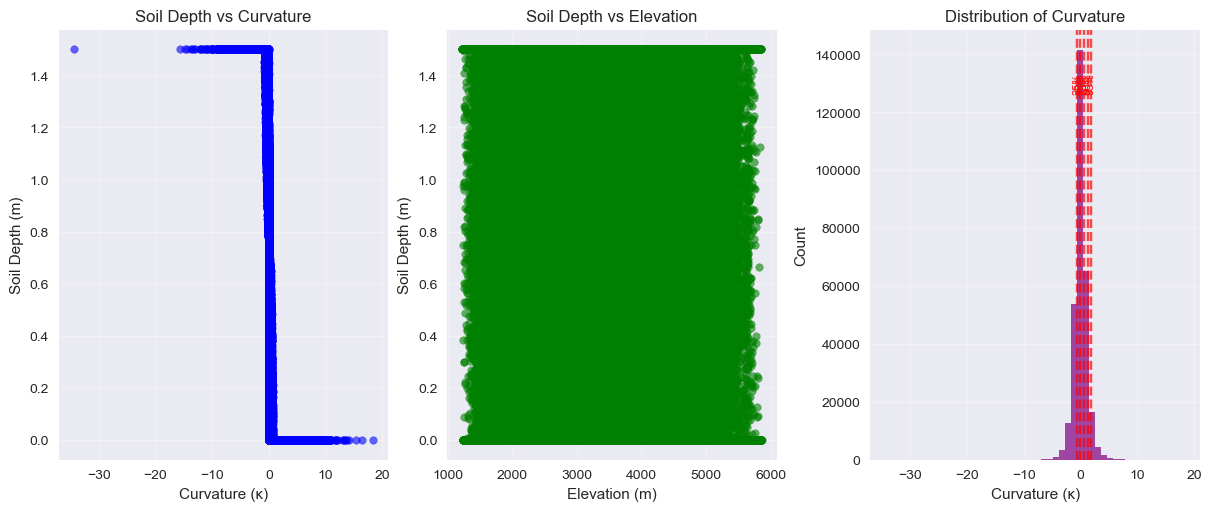

In [8]:
if 'soil__depth' not in mg.at_node:
    soil_depth = mg.add_zeros('soil__depth', at='node')

soil_depth = apply_soil_depth(
    grid=mg,
    max_soil_depth=config['soil_params']['max_soil_depth'],
    distribution=config['soil_params']['distribution'],
    relationship=config['soil_params']['relationship'],
    decay_rate=config['soil_params']['decay_rate'],
    exponent=config['soil_params']['exponent'],
    drainage_transform=config['soil_params']['drainage_transform'],
    drainage_threshold=config['soil_params']['drainage_threshold'],
    drainage_power=config['soil_params']['drainage_power'],
    P0=config['soil_params']['P0'],
    h_star=config['soil_params']['h_star'],
    D=config['soil_params']['D'],
    h_min=config['soil_params']['h_min'],
    h_no_ss=config['soil_params']['h_no_ss'],
    plot=config['soil_params']['plot_soil'],
)

# Bedrock elevation from DEM minus soil thickness
if 'bedrock__elevation' not in mg.at_node:
    mg.add_zeros('bedrock__elevation', at='node', clobber=True)
mg.at_node['bedrock__elevation'][:] = mg.at_node['topographic__elevation'] - mg.at_node['soil__depth']

print(f'Applied {config['soil_params']['distribution']}-based soil depth distribution')

logger.info(f"Applied {config['soil_params']['distribution']} soil depth distribution")

### Calculate slopes and topographic aspect

In [9]:
slopes_rad = mg.calc_slope_at_node(elevs='topographic__elevation')
slopes_deg = np.degrees(slopes_rad)
aspect_nodes = np.array(mg.calc_aspect_at_node(elevs='topographic__elevation',
                                                unit='degrees', ignore_closed_nodes=True))
aspect_nodes[mg.boundary_nodes] = np.nan
logger.info("Calculated slopes and aspect")

## Generate earthquake PGA grids
- Quickly sets up arrays for PGA_h and PGA_v using parameters set up above
- These can be "uniform", "circular", "square", "diamond", or "exponential" to test various patterns
- Can also be skipped if you have existing arrays of the same size as the grid

In [10]:
pga_h, pga_v = generate_acceleration_grid(
    grid=mg,
    horizontal_max=config['pga']['horizontal_max'],
    vertical_max=config['pga']['vertical_max'],
    distribution=config['pga']['distribution'],
    plot_grids=config['pga']['plot_grids'],
)
logger.info("Created earthquake PGA arrays")

uniform horizontal and vertical PGA arrays generated


## Initialise and run the ShallowLandslider component
- Parameters taken from dictionary at the top of the notebook
- If you want to compare model outputs with different parameter sets, toggle 'save_output_pickle' to True, and the outputs for each run will be saved to disk.
    - The runs can then be compared later.

In [11]:
# Initialise component
ls = ShallowLandslider(
    grid=mg,
    cohesion_eff=config['soil_params']['cohesion_eff'],
    angle_int_frict=config['soil_params']['angle_int_frict'],
    submerged_soil_proportion=config['soil_params']['submerged_soil_proportion'],
    pga_h=pga_h,
    pga_v=pga_v,
    pga_h_max=config['pga']['horizontal_max'],
    pga_v_max=config['pga']['vertical_max'],
    selection_method=config['simulation']['selection_method'],
    proportion_method=config['simulation']['proportion_method'],
    custom_proportion=config['simulation']['custom_proportion'],
    random_seed=config['simulation']['random_seed'],
    aspect_interval=config['simulation']['aspect_interval'],
    compute_displacement=config['simulation']['compute_displacement'],
    time_shaking=config['simulation']['time_shaking'],
    displacement_threshold=config['simulation']['displacement_threshold'],
    enable_runout=config['simulation']["enable_runout"],
    update_soil=config['simulation']["update_soil"],
    g=9.81,
    split_by_width_config=(None if kde_dict is None else {
        'kde_data': kde_dict.get('kde_data'),
        'kde_transform': kde_dict.get('kde_transform'),
        'convergence_threshold': 0.75,
        'min_region_size': 10,
        'max_iterations': 10,
        'width_threshold': 1.5,
    }),
    verbose=config['output']['verbose'],
)

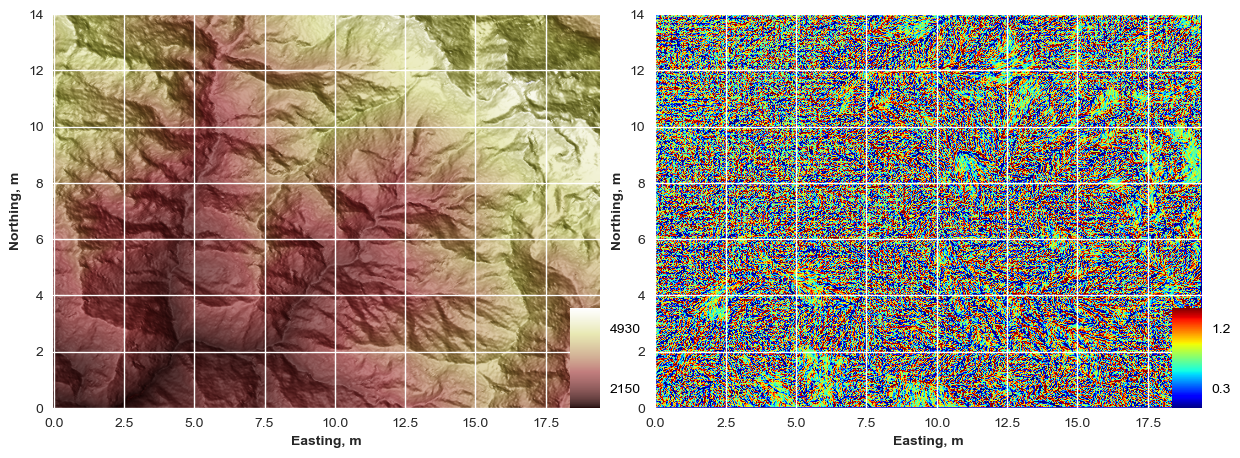

In [12]:
plt.figure(layout="constrained", figsize=(12, 8))
plt.subplot(121)
imshowhs_grid(
    ls.grid,
    "topographic__elevation",
    plot_type="DEM",
    allow_colorbar=True,
    cbar_or="vertical",
    ticks_km=True,
    cbar_loc="lower right",
    cbar_height=1.0,
    cbar_width=0.3,
)

plt.subplot(122)
imshowhs_grid(
    ls.grid,
    "topographic__elevation",
    plot_type="Drape1",
    drape1=np.ma.masked_invalid(ls.grid.at_node["soil__depth"]),
    cmap="jet",
    allow_colorbar=True,
    cbar_or="vertical",
    ticks_km=True,
    cbar_loc="lower right",
    cbar_height=1.0,
    cbar_width=0.3,
)
# plt.suptitle('planform_curvature')

plt.show()

In [13]:
# Run component
ls.run_one_step()

if config['output']['save_output_pickle']:
    pickle_dir = os.path.join(config["output"]["output_dir"], "pickled_runs")
    save_model_run(ls=ls, config=config, output_dir=pickle_dir)

# Extract results and set up for plotting
props = ls.results.get('group_properties')
# print('Group properties (head):')
print(props.head() if props is not None else 'No properties table computed.')

# Get labels and reshape to 2-D for draping
labels = mg.at_node['landslide__selected_labels'].copy().reshape(mg.shape)

# Mask out zeros
labels_masked = np.ma.masked_where(labels == 0, labels)

# Make a copy of the cmap and set masked values to transparent
cmap = plt.cm.get_cmap('jet').copy()
cmap.set_bad(alpha=0)  # masked pixels won't be visible

props_filtered = props.loc[props["selected"]]

# Extract measured landslide data
measured_spatial_stats_900greater = bundle.get("measured_spatial_stats_900greater")

Splitting by aspect: 100%|██████████| 3242/3242 [00:32<00:00, 99.11it/s] 



=== Iteration 1 ===
Calculating dimensions for 39775 regions...
Split 396 regions out of 1093
Conformance rate: 63.8%

=== Iteration 2 ===
Calculating dimensions for 40171 regions...
Split 36 regions out of 769
Conformance rate: 95.3%
Reached convergence threshold (75.0%). Stopping.

Completed recursive splitting:
Total splits performed: 432
Final number of regions: 40171
       max_elevation  median_elevation    area  slope_direction_length_new  \
label                                                                        
1             1504.0            1483.0  2700.0                   60.000000   
2             1781.0            1761.0  3600.0                   67.082039   
3             1763.0            1732.0  7200.0                   90.000000   
4             1841.0            1823.0  8100.0                  107.331263   
5             1695.0            1644.0  7200.0                  123.693169   

       perpendicular_width_new  local_relief  median_slope  mean_aspect  \
la

C:\Users\sghoshal\AppData\Local\Temp\ipykernel_16768\3323960282.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('jet').copy()


<Axes: xlabel='Easting, m', ylabel='Northing, m'>

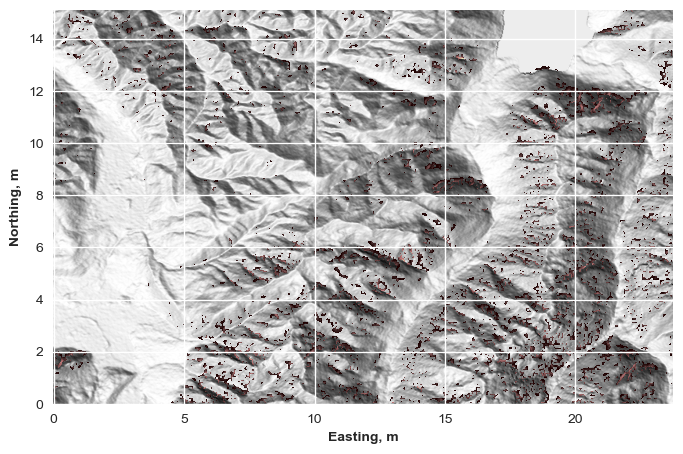

In [25]:
# ls.grid.at_node.keys()
imshowhs_grid(
            mg,
            "topographic__elevation",
            plot_type="Drape1",
            drape1=np.ma.masked_equal(ls._runout._last_erosion, 0),
            allow_colorbar=False,
            cbar_or="vertical",
            ticks_km=True,
            cbar_loc="lower right",
            cbar_height=0.8,
            cbar_width=0.3,
        )


<Axes: xlabel='Easting, m', ylabel='Northing, m'>

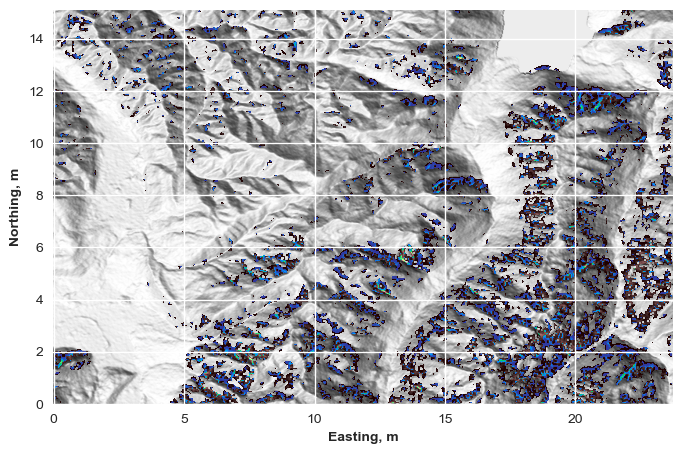

In [27]:

imshowhs_grid(
            mg,
            "topographic__elevation",
            plot_type="Drape2",
            drape1=np.ma.masked_equal(ls._runout._last_deposition, 0),
            drape2=np.ma.masked_equal(ls._runout._last_erosion, 0),
            allow_colorbar=False,
            cbar_or="vertical",
            ticks_km=True,
            cbar_loc="lower right",
            cbar_height=0.8,
            cbar_width=0.3,
        )

## Visualise simulated landslides
- Plots a figure with four panels:
    1. Simulated landslides draped over hillshade
    2. Histogram and ecdf of landslide area (mapped vs. simulated)
    3. Histogram and ecdf of mean landslide elevations (mapped vs. simulated)
    4. Histogram and ecdf of mean landslide slopes (mapped vs. simulated)
- *Only* compares modelled data with all measured data, rather than data clipped to subregions.

In [15]:
len(props_filtered)

10043

KeyError: 'Area_m2'

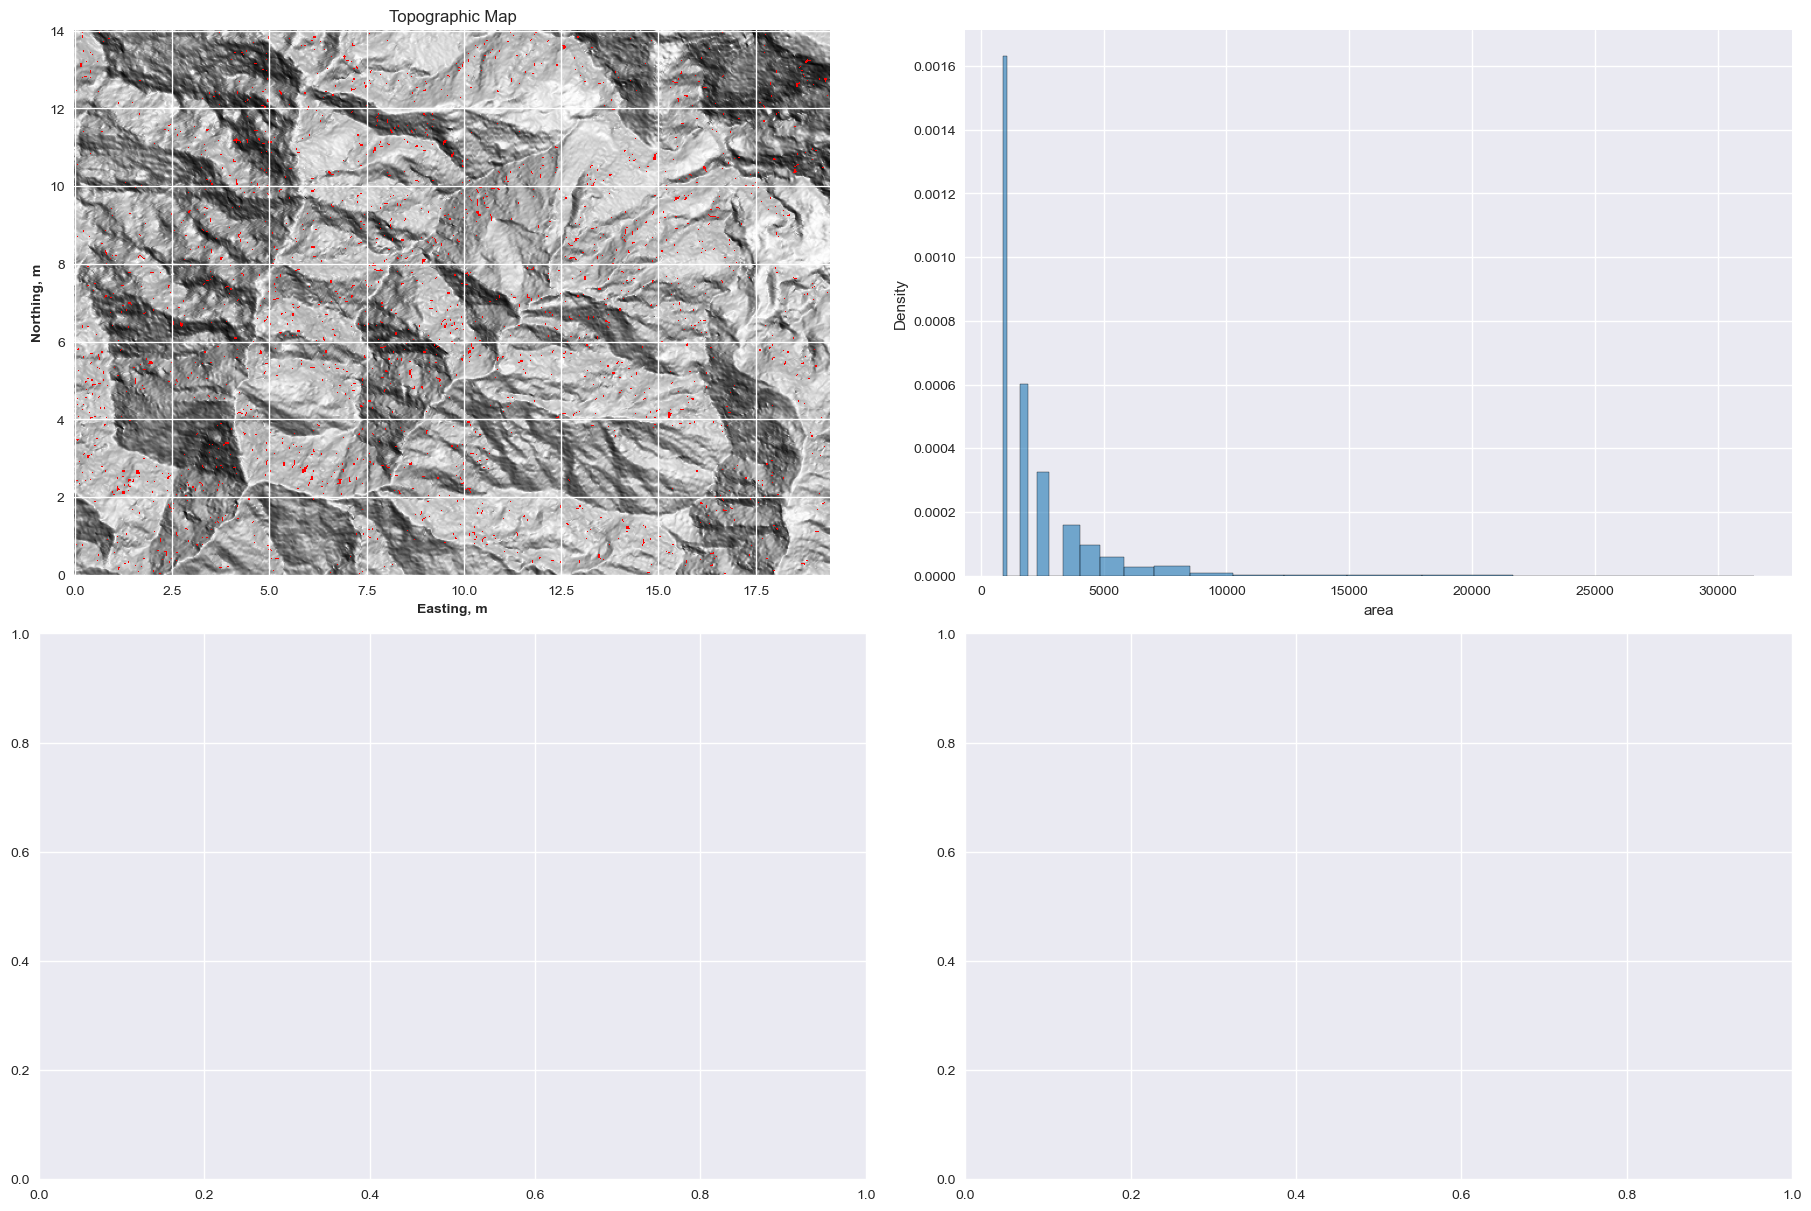

In [14]:
plot_comparison_panels_with_ecdf(
    observed_df=measured_spatial_stats_900greater,
    model_df=props_filtered,
    mg=mg,                     # optional
    labels_masked=labels_masked,  # optional
    title=f"Modeled output: {config['soil_params']['distribution']} - {config['soil_params']['relationship']}",
    save_path=None             # or "comparison_panels.pdf"
)

## Compare different runs
- If 'save_output_pickle' was toggled to `True`, then you can run the next few cells to compare the results of different runs.

In [30]:
runs = load_all_runs(pickle_dir)
dfs = extract_selected_group_props(runs_dict=runs, name_style="string")

column_mapping = {
    # observed_col: modeled_col
    "Area_m2": "area",
    "Elevation_m_mean": "median_elevation",
    "Slope_deg_mean": "median_slope",
    "Aspect_deg_median": "mean_aspect",
}

try:
    from astropy.stats import kuiper_two

    HAS_ASTROPY = True
except ImportError:
    HAS_ASTROPY = False

Loading pickle files:
File: SRTMGL1_c15000_curvature_linear_std_local_seed5000.pkl
  Parsed params: {'dem_type': 'SRTMGL1', 'cohesion_eff': 15000, 'distribution': 'curvature', 'relationship': 'linear', 'curvature_variant': 'std_local', 'random_seed': 5000}
  Key: (15000, 'curvature', 'linear', 'std_local', 5000)



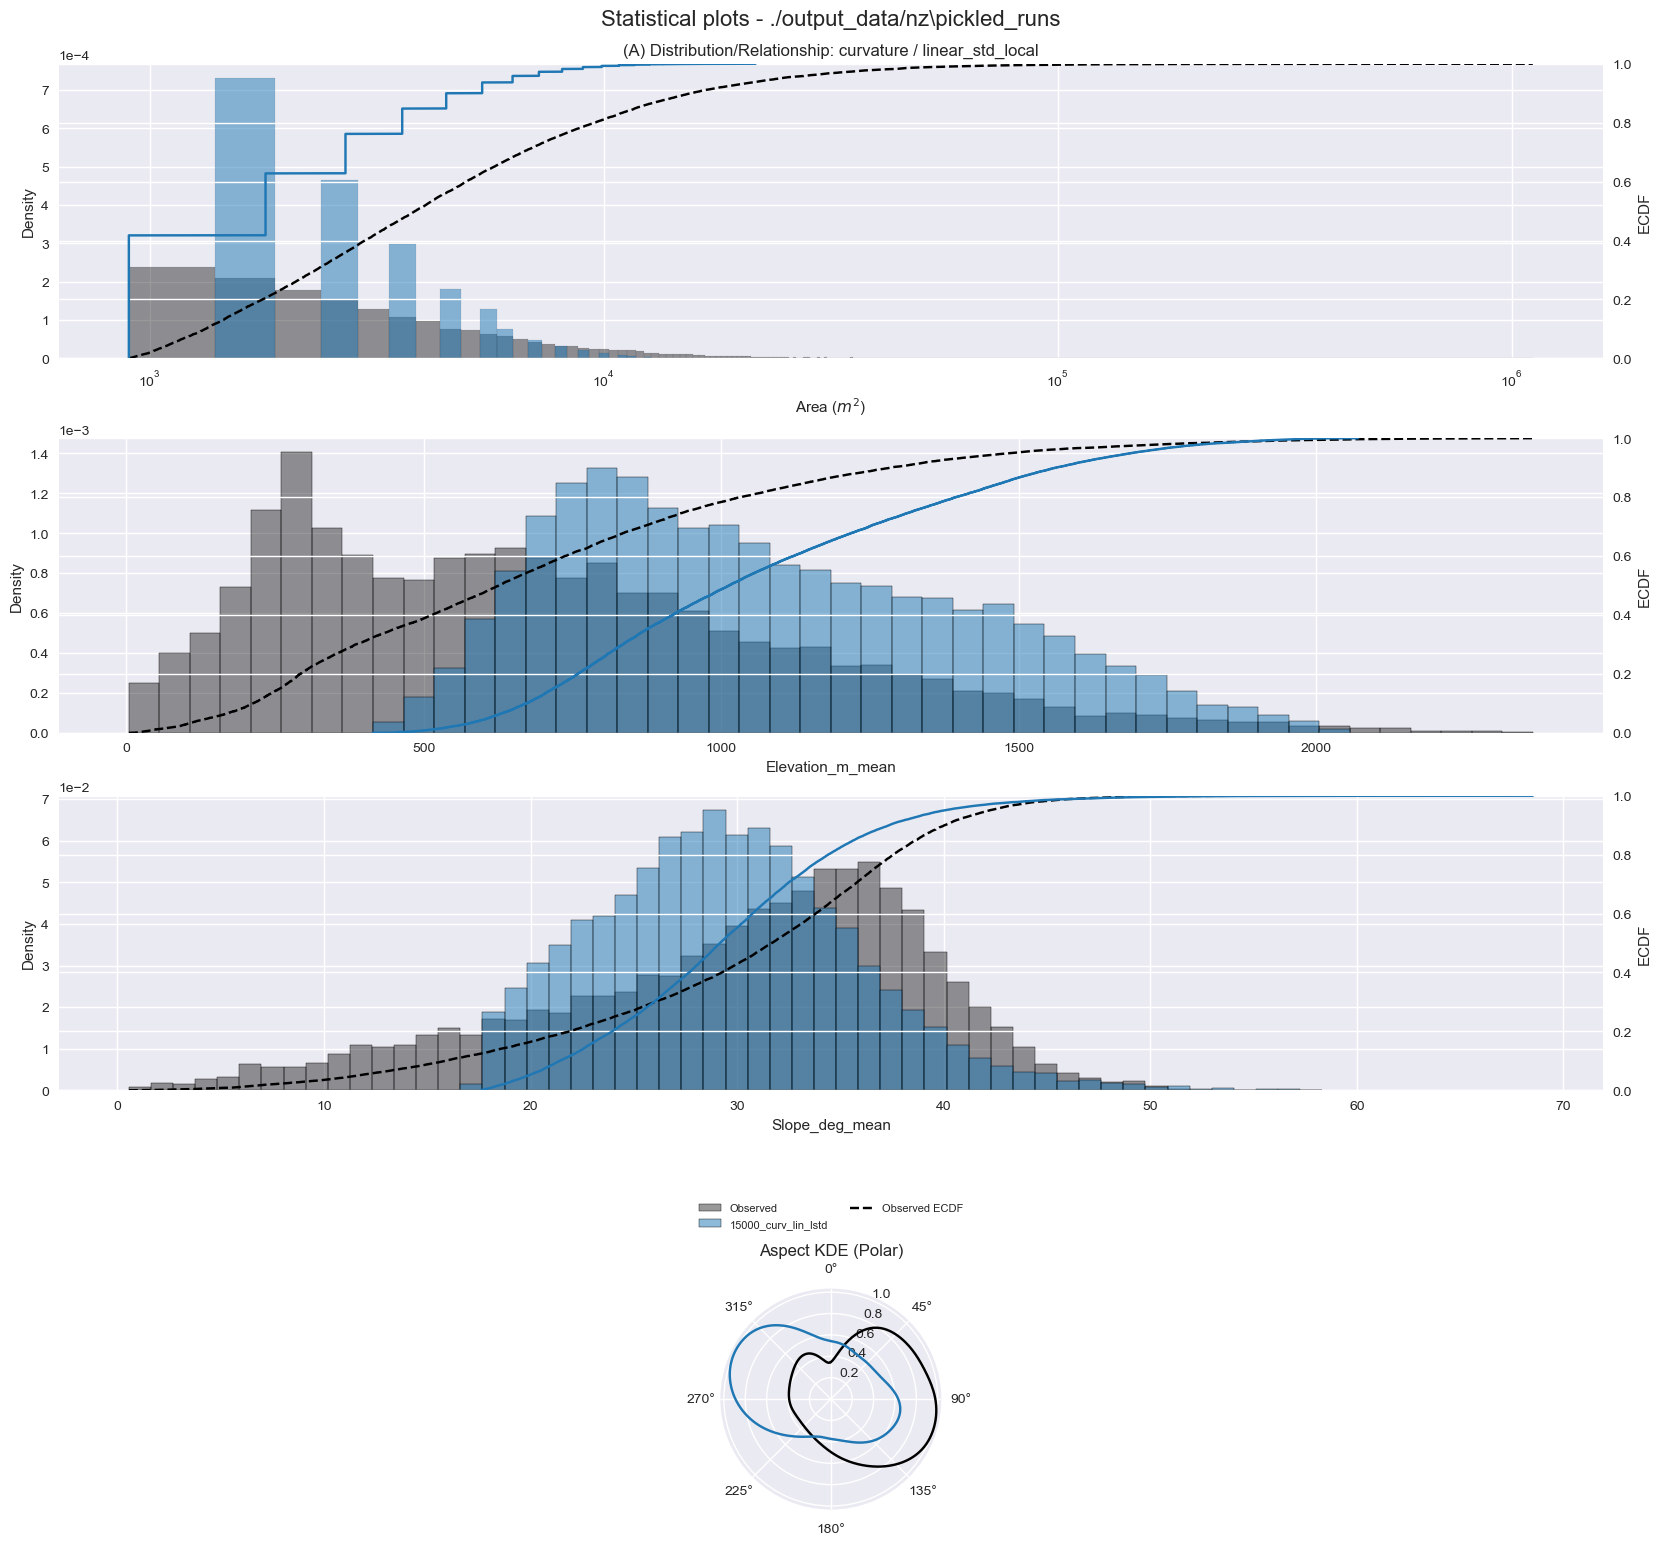

In [ ]:
# %% Plot histograms for area, slope and elevation

plot_histograms_ecdfs_combined(observed_df=measured_spatial_stats_900greater,
    model_dfs_dict=dfs,
    column_mapping=column_mapping,
    custom_names=True,
    subregion_folder=pickle_dir,
    save_plots=False
    )

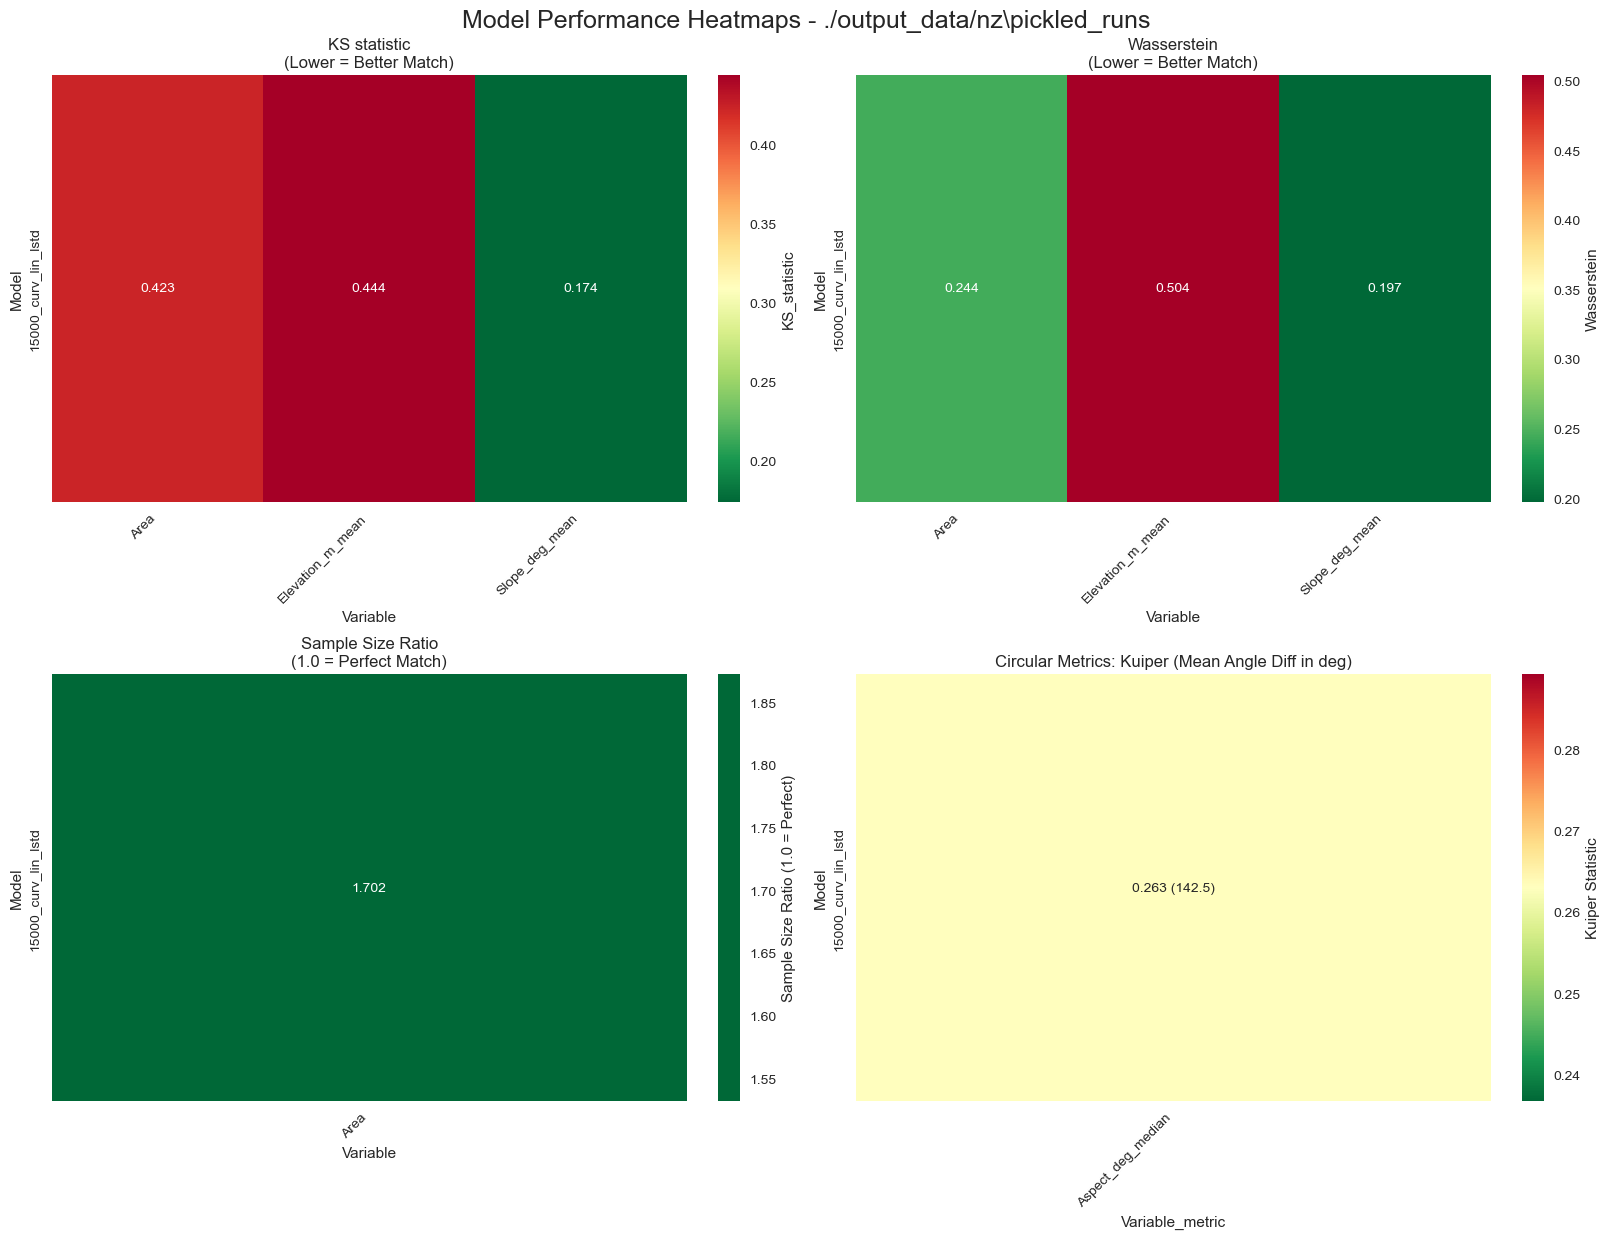

In [31]:
# %% Plot heatmap
all_metrics = create_performance_summary(
    observed_df=measured_spatial_stats_900greater,
    model_dfs_dict=dfs,
    column_mapping=column_mapping,
    has_astropy=HAS_ASTROPY,
    subregion_folder=pickle_dir,
    save_plots=False
)


## Troubleshooting & Tips

- **Field names** follow the Landlab convention used in the component (e.g., `topographic__elevation`, `soil__depth`).
- If you see a `ValueError` about sizes, ensure arrays match `mg.number_of_nodes`.
- If DEM fetching requires authentication/API keys, set `dem_info.api_key` appropriately.
- Use `selection_method='pga_weighted'` for a deterministic proportion based on PGA; otherwise keep `'probabilistic'`.
- Turn on `compute_displacement=True` to write `landslide__newmark_displacement`.
- Set `aspect_interval` to a coarser (e.g., 45°) if too many subgroups are created.
- For reproducibility, set `random_seed`.
- For very small regions, consider post‑processing with `handle_small_regions` in your helper functions or merge/keep logic.

> For performance on large domains, start with smaller extents and lower `smooth_num`, and avoid plotting huge arrays.
